## load chimera and data

In [1]:
import os, sys
os.environ['CHIMERA_ENABLE_GPU'] = "False"
sys.path.append(os.getcwd()+'/../')

from CHIMERA import data

# Import CHIMERA modules

# Data paths based on parameters
dir_data = "/leonardo_work/IscrC_LIGEA3/O5_B25/data/"

mock_id = 1
mcut = 10 

file_gw_ev_pixelated = './data/O5snr25_100evs_mock1_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
file_inj = './data/injections_Ninj_2e7_O5Like_snr20.h5'

file_compl_mask = f"./data/completeness_masks_5x_pix32False.h5"
file_compl_intp = f"./data/completeness_masks_5x_pix32False_mock{mock_id}_mcut{mcut}.h5"
dir_temp_mask_idx = f"./data/temp_gw_mask_idxs_mock{mock_id}_mcut{mcut}.h5"

# 1. Load data 
"""
gw_cat = data.load_gw_pe_samples(file_ev)
gw_cat = gw_cat.update(pe_prior = gw_cat.dL**2)
nside_list = [512, 256, 128, 64, 32, 16, 8]
mean_npixels_event = 15
prefix = f"./O5snr25_100evs_mock{mock_id}"
nest = False
sky_conf = 0.9
pix_cat = data.pixelize_gw_catalog(gw_cat,
                       nside_list,
                       mean_npixels_event,
                       sky_conf,
                       nest,
                       prefix,
                       ret_datastruct=True)
"""
gw_pix_cat = data.load_pixelated_gw_catalog(file_gw_ev_pixelated)

inj_data = data.load_injection_data(file_inj, snr_cut=25)

2026-06-08 14:38:32,282 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: False


# population model

In [2]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass.conditioned import plp
from CHIMERA.rate import madau_dickinson

cosmo = flrw(H0=70, Om0=0.25)
mass_params = {'m_low':5.1, 'm_high':87., 'lambda_peak':0.039, 'alpha':3.4, 'beta':1.1, 'delta_m':4.8, 'mu_g':34., 'sigma_g':3.6}
mass  = plp(**mass_params)
rate  = madau_dickinson(gamma=2.7, kappa = 3, zp= 2)

## schechter function and completeness

In [3]:
from CHIMERA.completeness import mask_completeness
from CHIMERA.catalog import pixelated_catalog, load_p_cat
from CHIMERA.utils import mags
from CHIMERA.utils import io as ioc

evsch = mags.EvolvingDoubleSchechter(zkind="poly", params=mags.SchecheterParsMICE_B25, z_max=1.4, z_min=0.07296)
evsch.M_min_fcn = lambda z: 2.89766937 + 5.32024468*(1+z) - 1.04370681*(1+z)**2

# completeness
compl = mask_completeness(cosmo, lambda z: evsch.weighted_density(z, 1), None,
                          dir_masks=file_compl_mask, dir_compl = file_compl_intp,
                          z_min = evsch.z_min, z_max = evsch.z_max,
                          )
ioc.load_set(compl, dir_temp_mask_idx, datasets=["gw_mask_idxs"])

# precomputed elesewhere due to very big gaalxy catalog
# z_grids will be used as th eintegration grid
p_cat, N_gal, P_compl, z_grids = load_p_cat("./data/pcat_incomplete.h5") 

gal_cat = pixelated_catalog(compl, p_cat, N_gal, P_compl, z_grids)

2026-06-08 14:38:36,210 - CHIMERA - INFO - Initializing `masked_completeness`:
2026-06-08 14:38:36,211 - CHIMERA - INFO -  > Loading masks from ./data/completeness_masks_5x_pix32False.h5
2026-06-08 14:38:36,746 - CHIMERA - INFO -    - Loaded 5 masks with nside=32, nest=False
2026-06-08 14:38:37,683 - CHIMERA - INFO -    - Pixels per mask: [10688    32   430   844   294]
2026-06-08 14:38:37,685 - CHIMERA - INFO -    - Galaxies per mask: [        0      1347  81461950 184350218  68951562]
2026-06-08 14:38:37,685 - CHIMERA - INFO -  > Loading interpolants from ./data/completeness_masks_5x_pix32False_mock1_mcut10.h5
2026-06-08 14:38:37,773 - CHIMERA - INFO -    - Loaded 5 interpolants with shape=(5, 1000), z_int_range=[0.0, 10.0]
2026-06-08 14:38:37,786 - CHIMERA - INFO - Loading p_cat from './data/pcat_incomplete.h5'


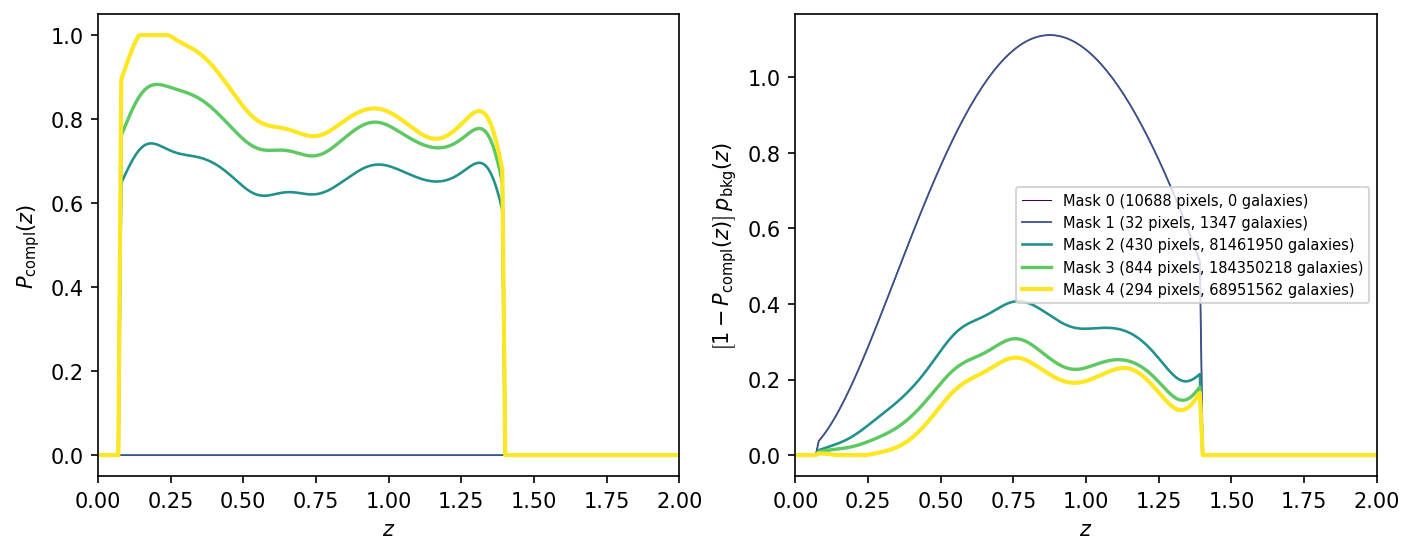

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from CHIMERA.data import theta_src
import jax.numpy as jnp

fig, ax = plt.subplots(1,2, figsize=(11, 4), dpi=150)

colors = plt.cm.viridis(jnp.linspace(0, 1, compl.nmasks))
lws = np.linspace(.5,2, compl.nmasks)

p_bkg = compl.p_bkg(cosmo, compl.z_int_grid)

for i in range(compl.nmasks):
    ax[0].plot(compl.z_int_grid, compl.completeness[i], color=colors[i], lw=lws[i],
               label=f'Mask {i} ({compl.npix_mask[i]} pixels, {compl.ngal_mask[i]} galaxies)')

    ax[1].plot(compl.z_int_grid, (1-compl.completeness[i])*p_bkg, color=colors[i], lw=lws[i],
               label=f'Mask {i} ({compl.npix_mask[i]} pixels, {compl.ngal_mask[i]} galaxies)')

[ax[i].set_xlim(0,2) for i in [0,1]]
[ax[i].set_xlabel(r"$z$") for i in [0,1]]
ax[0].set_ylabel(r"$P_{\rm compl}(z)$")
ax[1].set_ylabel(r"$\left[1-P_{\rm compl}(z)\right]\,p_{\rm bkg}(z)$")
ax[1].legend(fontsize=7)
plt.show()

## redshift grids, population rate, and selection function

In [5]:
from CHIMERA import population
from CHIMERA import selection_function

# pop model, selection_function 
pop = population(cosmo, mass, rate, gal_cat=gal_cat)
sel_fcn = selection_function(inj_data,  N_inj=20*1e6)

## hyperlike

In [6]:
from CHIMERA import hyperlikelihood

hyperlike = hyperlikelihood(
    # data
    gw_pix_cat,
    # pop model
    population=pop,
    # selection function
    selection_function=sel_fcn,
    # numerical stability
    pe_neff = 2.0,
    inj_neff = None, # default to 5*Nev  
    # KDE settings
    kind_kde = 'single-1d-binned',
    kernel='epan', # 'epan'
    kde_bw=None,
    cut_grid=2,
    num_bins=200,
)


2026-06-08 14:38:43,898 - CHIMERA - WARNING - `kde_bw` is None, using Scott rule for bandwidth.
2026-06-08 14:38:43,970 - CHIMERA - INFO - Created hyperlikelihood model. Using 100 GW events.


50it [00:37,  1.35it/s]
/tmp/ipykernel_10619/4280466871.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)
/tmp/ipykernel_10619/4280466871.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  like_H0 /= np.trapz(like_H0, H0)


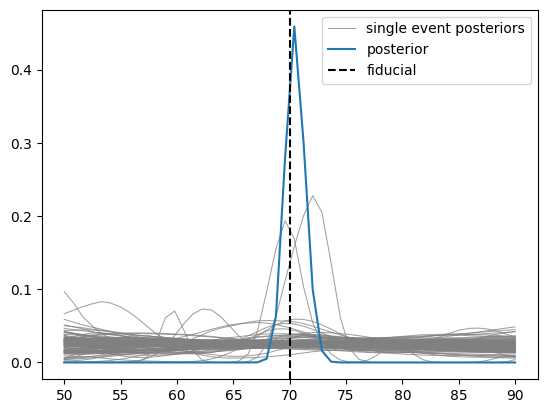

In [7]:
import numpy as np
import tqdm
import matplotlib.pyplot as plt

H0 = np.linspace(50, 90, 50)
log_like_evs_H0 = np.zeros((H0.shape[0], hyperlike.nevents))
loglike_H0 = np.zeros_like(H0)
N_exp_H0 = np.zeros_like(H0)

for i, h0 in tqdm.tqdm(enumerate(H0)):
  log_like_evs, N_exp, neff_inj, log_hyperlike = hyperlike.compute_all(H0=h0)
  log_like_evs_H0[i] = log_like_evs
  N_exp_H0[i] = N_exp
  loglike_H0[i] = log_hyperlike

# exponentiate and normalize
log_like_evs_H0 -= np.nanmax(log_like_evs_H0)
like_evs_H0 = np.exp(log_like_evs_H0) 
norms_evs = np.trapz(like_evs_H0, x=H0, axis=0)

loglike_H0 -= np.nanmax(loglike_H0)
like_H0 = np.exp(loglike_H0)
like_H0 /= np.trapz(like_H0, H0)

for e in range(hyperlike.nevents):
    lab = 'single event posteriors' if e == 0 else None
    plt.plot(H0, like_evs_H0[:,e]/norms_evs[e], c='gray', lw=0.75, alpha=0.75, label = lab )
plt.plot(H0, like_H0, label='posterior')
plt.axvline(70, ls='--', c='k', label= 'fiducial')
plt.legend()
plt.show()

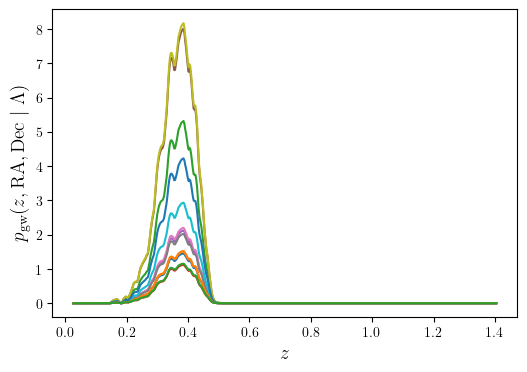

In [8]:
from CHIMERA.utils.plotting import plot_p_cat_pixelated, plot_p_gal_pixelated, plot_p_gw3d_pixelated

event = 0
plot_p_gw3d_pixelated(hyperlike, event)
plt.show()

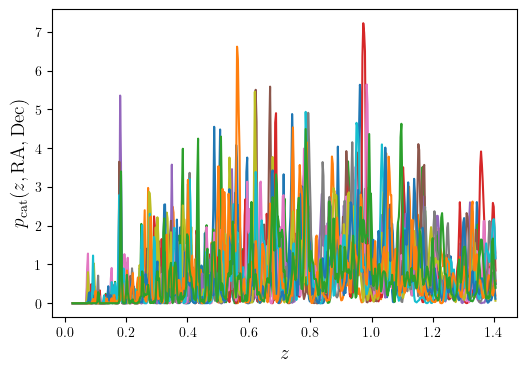

In [9]:
plot_p_cat_pixelated(hyperlike, event)
plt.show()

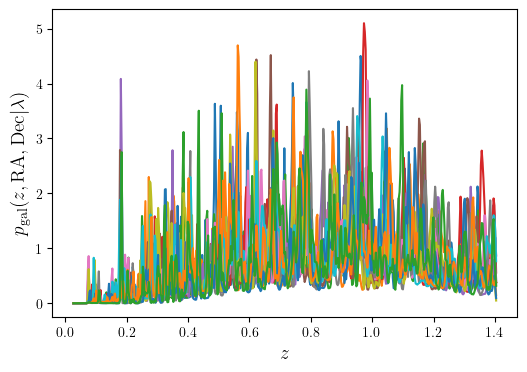

In [10]:
plot_p_gal_pixelated(hyperlike, event)
plt.show()